# Understanding Data Distribution Patterns

**Author:** Mitadru Deb  
**Date:** February 2026

This notebook analyzes the distribution of key variables in the developer survey dataset, including job satisfaction, programming languages, experience levels, and remote work trends.

## Importing Libraries

I'll start by importing the necessary libraries for data analysis and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Loading the Dataset

I'll load the survey data and take a quick look at the first few rows.

In [2]:
# Load the survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display first few rows
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Examining Data Structure

Let me understand the structure of the dataset by checking column names, data types, and basic information.

In [3]:
# Get dataset information
print("Dataset Info:")
print(df.info())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes.value_counts())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB
None

Column names:
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired'

## Handling Missing Data

I'll identify missing values and decide how to handle them.

In [4]:
# Check for missing values
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage': missing_percent
})

# Show columns with missing values
print("Columns with missing values:")
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False).head(15))

Columns with missing values:
                               Missing Count  Percentage
AINextMuch less integrated             64289       98.25
AINextLess integrated                  63082       96.40
AINextNo change                        52939       80.90
AINextMuch more integrated             51999       79.46
EmbeddedAdmired                        48704       74.43
EmbeddedWantToWorkWith                 47837       73.10
EmbeddedHaveWorkedWith                 43223       66.05
ConvertedCompYearly                    42002       64.19
AIToolNot interested in Using          41023       62.69
AINextMore integrated                  41009       62.67
Knowledge_9                            37802       57.77
Frequency_3                            37727       57.65
Knowledge_8                            37679       57.58
ProfessionalTech                       37673       57.57
Knowledge_7                            37659       57.55


In [5]:
# Create a working copy and handle critical missing values
df_clean = df.copy()

# Drop rows with missing Employment data if the column exists
if 'Employment' in df_clean.columns:
    df_clean = df_clean.dropna(subset=['Employment'])

print(f"Rows after handling missing data: {df_clean.shape[0]}")

Rows after handling missing data: 65437


## Analyzing Key Columns

Let me examine the distribution of important columns like Employment, Job Satisfaction, and Years of Experience.

In [6]:
# Analyze Employment column
if 'Employment' in df_clean.columns:
    print("Employment Status Distribution:")
    print(df_clean['Employment'].value_counts())
    print()

Employment Status Distribution:
Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but loo

In [7]:
# Analyze Job Satisfaction
if 'JobSat' in df_clean.columns:
    print("Job Satisfaction Distribution:")
    print(df_clean['JobSat'].value_counts())
    print()

Job Satisfaction Distribution:
JobSat
8.0     7509
7.0     6379
6.0     3751
9.0     3626
10.0    2251
5.0     1956
3.0     1165
4.0     1130
2.0      772
0.0      311
1.0      276
Name: count, dtype: int64



In [8]:
# Analyze Years of Professional Coding
if 'YearsCodePro' in df_clean.columns:
    print("Professional Coding Experience:")
    print(df_clean['YearsCodePro'].describe())
    print()
    print("Top experience levels:")
    print(df_clean['YearsCodePro'].value_counts().head(10))

Professional Coding Experience:
count     51610
unique       52
top           2
freq       4168
Name: YearsCodePro, dtype: object

Top experience levels:
YearsCodePro
2                   4168
3                   4093
5                   3526
10                  3251
4                   3215
Less than 1 year    2856
6                   2843
1                   2639
8                   2549
7                   2517
Name: count, dtype: int64


## Visualizing Job Satisfaction Distribution

I'll create visualizations to better understand job satisfaction patterns.

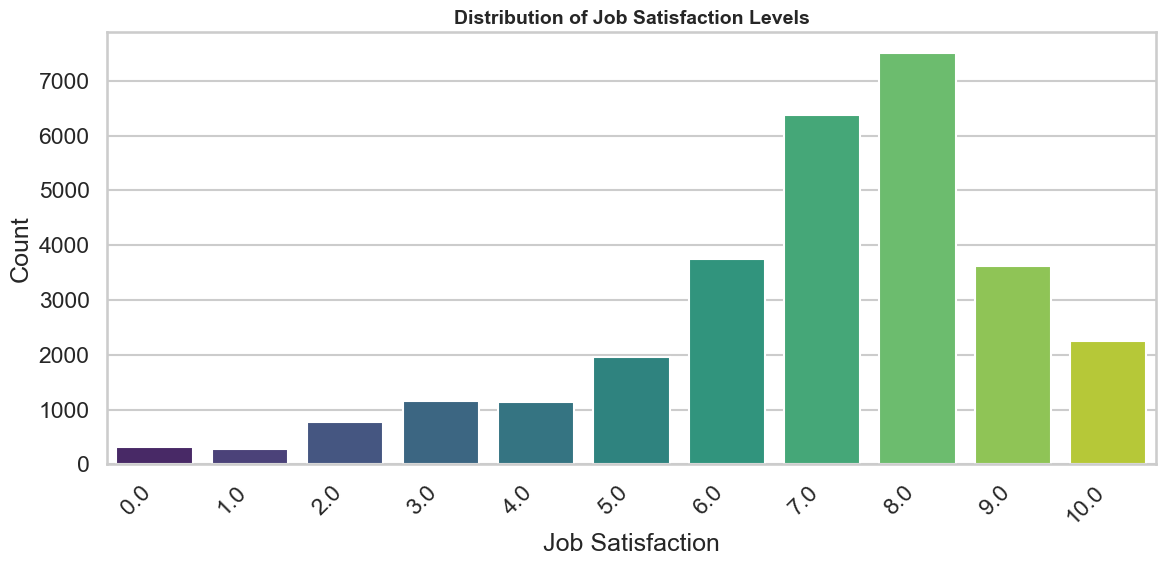

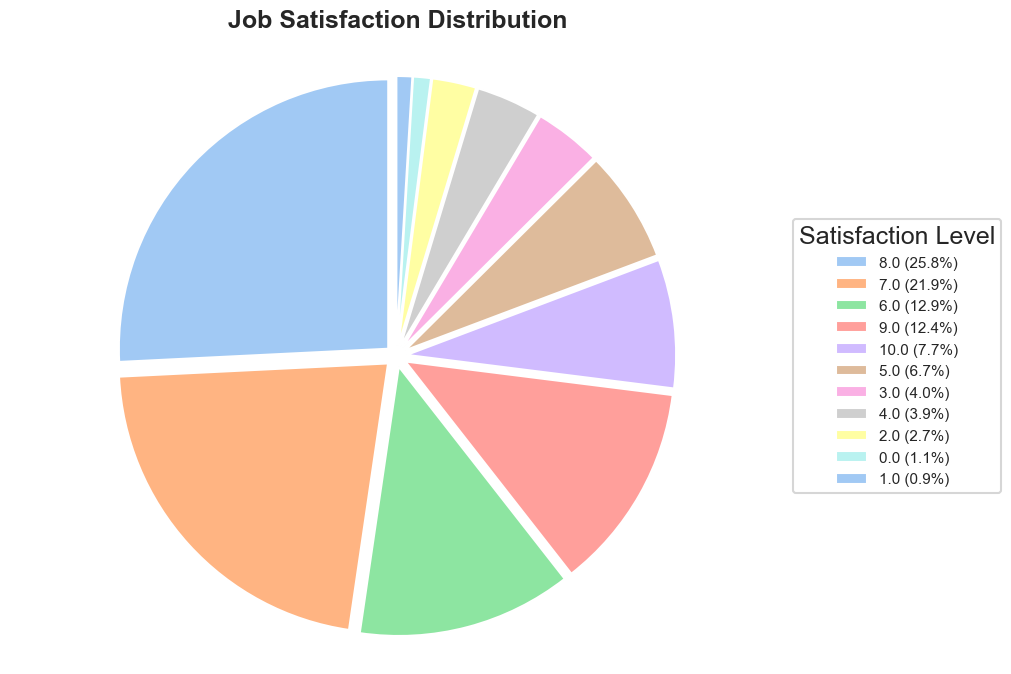

In [18]:
# Visualize Job Satisfaction
if 'JobSat' in df_clean.columns:
    # Remove missing values for visualization
    jobsat_data = df_clean['JobSat'].dropna()
    
    # Create count plot
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df_clean, x='JobSat', hue='JobSat', palette='viridis', legend=False)
    plt.title('Distribution of Job Satisfaction Levels', fontsize=14, fontweight='bold')
    plt.xlabel('Job Satisfaction')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Create pie chart
   
    sns.set_style("white")
    sns.set_context("talk")

    # Count values
    jobsat_counts = jobsat_data.value_counts()

    plt.figure(figsize=(10, 8))

    colors = sns.color_palette("pastel")

    wedges, texts = plt.pie(
    jobsat_counts,
    startangle=90,
    explode=[0.04]*len(jobsat_counts),
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )

    # Create legend with percentages
    total = jobsat_counts.sum()
    labels = [f"{label} ({count/total*100:.1f}%)"
          for label, count in zip(jobsat_counts.index, jobsat_counts)]

    plt.legend(
    wedges,
    labels,
    title="Satisfaction Level",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=11
    )

    plt.title(
    "Job Satisfaction Distribution",
    fontsize=18,
    fontweight="bold",
    pad=15
    )

    plt.axis('equal')
    plt.show()


## Programming Languages Analysis

I'll analyze which programming languages developers have worked with and want to work with.

Top 10 Languages Developers Have Worked With:
LanguageHaveWorkedWith
JavaScript                 37492
HTML/CSS                   31816
Python                     30719
SQL                        30682
TypeScript                 23150
Bash/Shell (all shells)    20412
Java                       18239
C#                         16318
C++                        13827
C                          12184
Name: count, dtype: int64


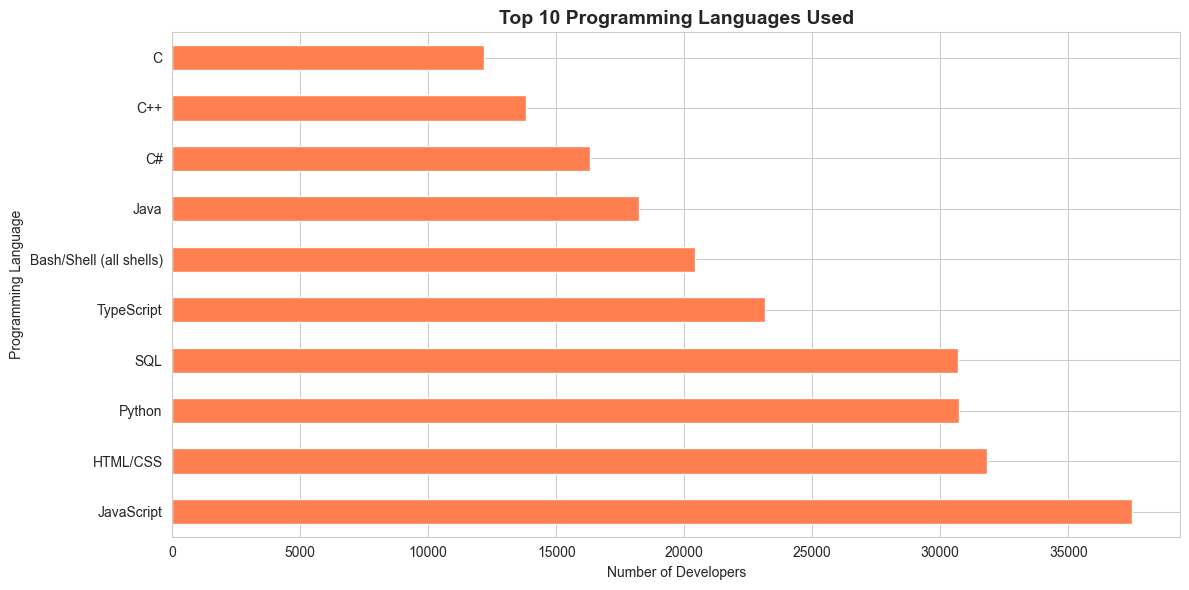

In [10]:
# Check for language columns
worked_col = 'LanguageHaveWorkedWith' if 'LanguageHaveWorkedWith' in df_clean.columns else 'LanguageWorkedWith'
want_col = 'LanguageWantToWorkWith'

if worked_col in df_clean.columns:
    # Get languages worked with
    languages_worked = df_clean[worked_col].dropna()
    
    # Split by semicolon if multiple languages
    if languages_worked.str.contains(';').any():
        all_worked = languages_worked.str.split(';').explode()
        top_worked = all_worked.value_counts().head(10)
        
        print("Top 10 Languages Developers Have Worked With:")
        print(top_worked)
        
        # Visualize
        plt.figure(figsize=(12, 6))
        top_worked.plot(kind='barh', color='coral')
        plt.title('Top 10 Programming Languages Used', fontsize=14, fontweight='bold')
        plt.xlabel('Number of Developers')
        plt.ylabel('Programming Language')
        plt.tight_layout()
        plt.show()
else:
    print("Language column not found")


Top 10 Languages Developers Want to Work With:
LanguageWantToWorkWith
Python                     25047
JavaScript                 23774
SQL                        22400
HTML/CSS                   20721
TypeScript                 20239
Rust                       17232
Go                         13837
Bash/Shell (all shells)    13744
C#                         12921
C++                        10873
Name: count, dtype: int64


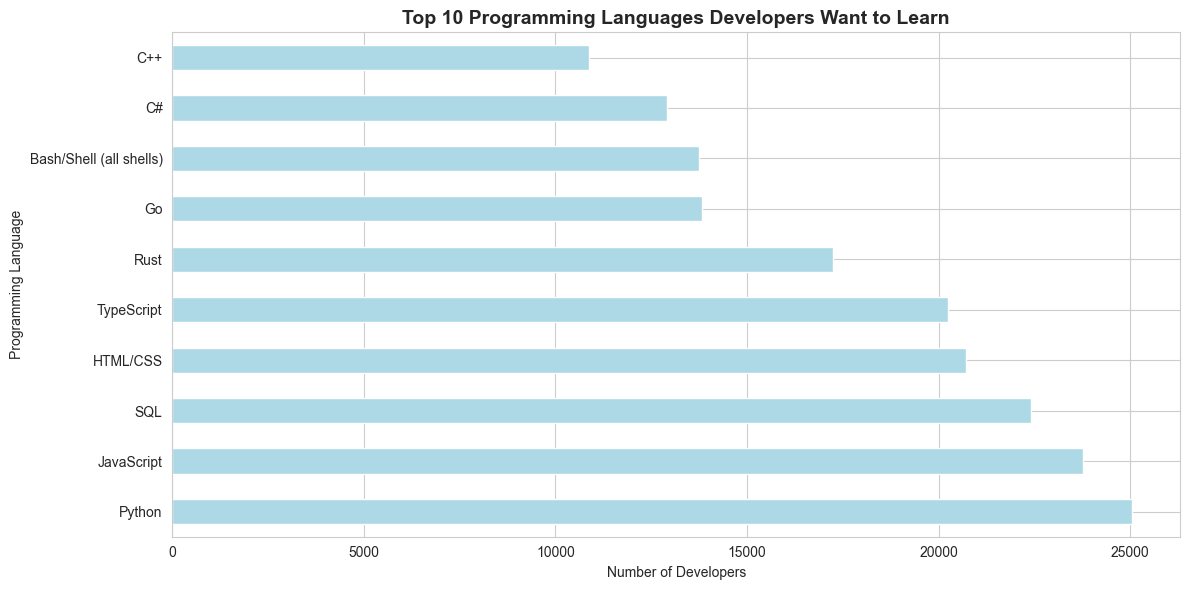

In [11]:
# Languages developers want to work with
if want_col in df_clean.columns:
    languages_want = df_clean[want_col].dropna()
    
    if languages_want.str.contains(';').any():
        all_want = languages_want.str.split(';').explode()
        top_want = all_want.value_counts().head(10)
        
        print("\nTop 10 Languages Developers Want to Work With:")
        print(top_want)
        
        # Visualize
        plt.figure(figsize=(12, 6))
        top_want.plot(kind='barh', color='lightblue')
        plt.title('Top 10 Programming Languages Developers Want to Learn', fontsize=14, fontweight='bold')
        plt.xlabel('Number of Developers')
        plt.ylabel('Programming Language')
        plt.tight_layout()
        plt.show()

## Remote Work Trends Analysis

Let me analyze remote work preferences across different regions.

Remote Work Distribution:
RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64


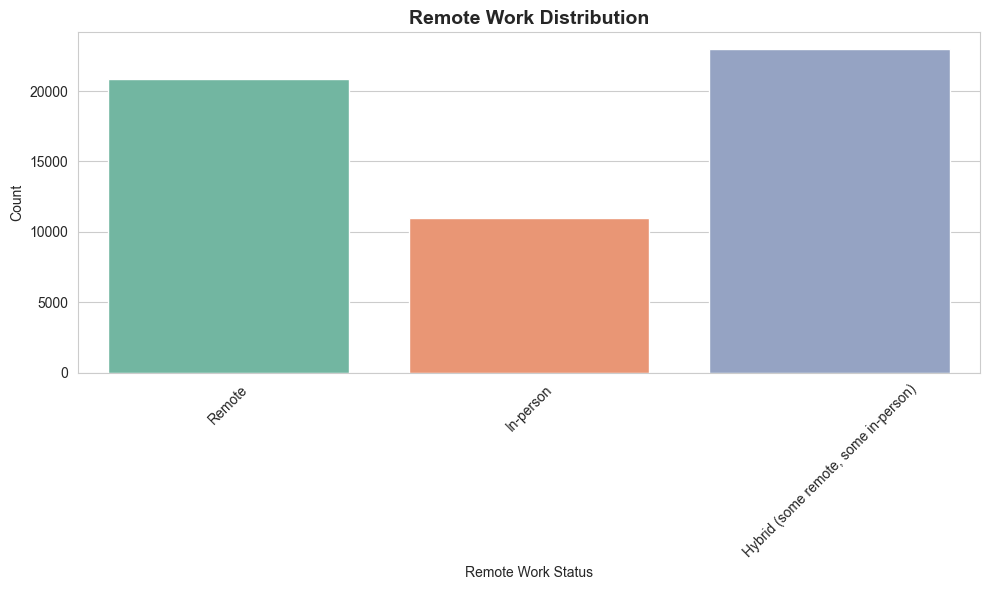

In [12]:
# Analyze remote work distribution
if 'RemoteWork' in df_clean.columns:
    print("Remote Work Distribution:")
    print(df_clean['RemoteWork'].value_counts())
    
    # Visualize
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_clean, x='RemoteWork', hue='RemoteWork', palette='Set2', legend=False)
    plt.title('Remote Work Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Remote Work Status')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Remote Work by Top 10 Countries:
RemoteWork                                          Hybrid (some remote, some in-person)  \
Country                                                                                    
Brazil                                                                               311   
Canada                                                                               631   
France                                                                              1041   
Germany                                                                             2421   
India                                                                               1196   
Netherlands                                                                          829   
Poland                                                                               458   
Ukraine                                                                              492   
United Kingdom of Great Britain and Northern I

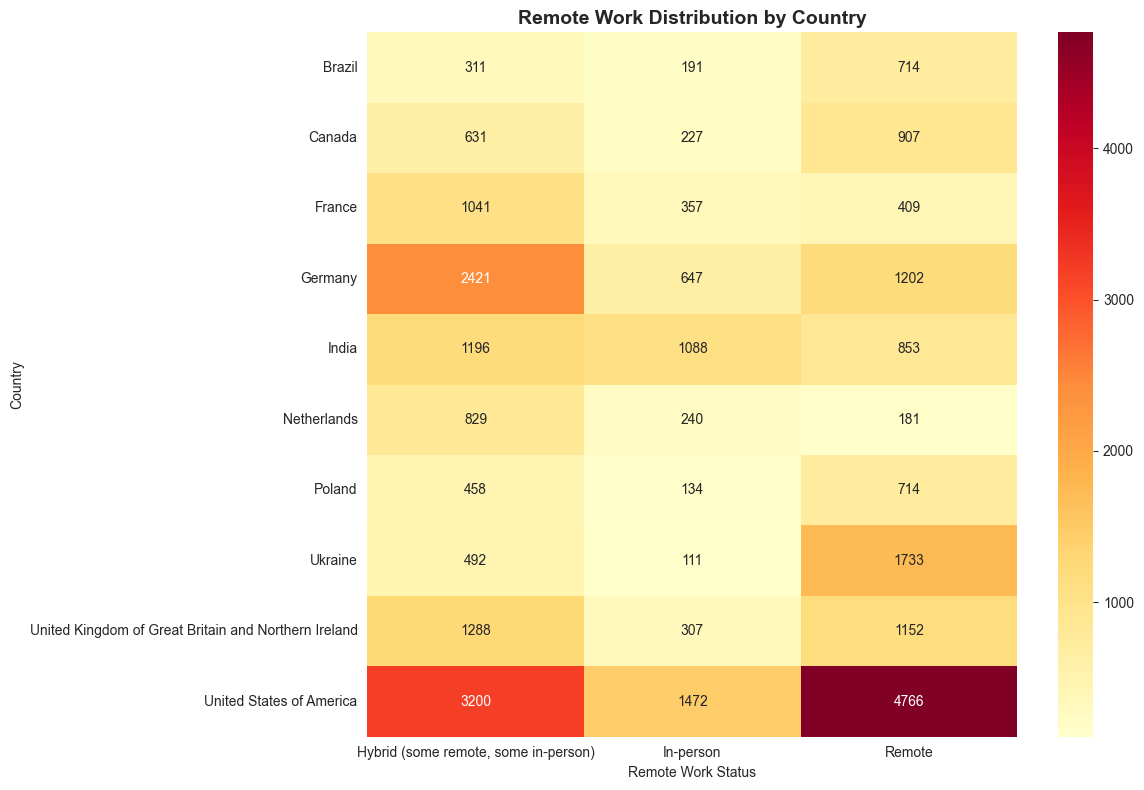

In [13]:
# Remote work by country (top 10 countries)
if 'RemoteWork' in df_clean.columns and 'Country' in df_clean.columns:
    # Get top 10 countries
    top_countries = df_clean['Country'].value_counts().head(10).index
    df_top_countries = df_clean[df_clean['Country'].isin(top_countries)]
    
    # Create cross-tabulation
    remote_by_country = pd.crosstab(df_top_countries['Country'], df_top_countries['RemoteWork'])
    print("\nRemote Work by Top 10 Countries:")
    print(remote_by_country)
    
    # Visualize with heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(remote_by_country, annot=True, fmt='d', cmap='YlOrRd')
    plt.title('Remote Work Distribution by Country', fontsize=14, fontweight='bold')
    plt.xlabel('Remote Work Status')
    plt.ylabel('Country')
    plt.tight_layout()
    plt.show()

## Correlation: Job Satisfaction vs Experience

I'll analyze the relationship between years of experience and job satisfaction.

Correlation between Experience and Job Satisfaction: 0.103


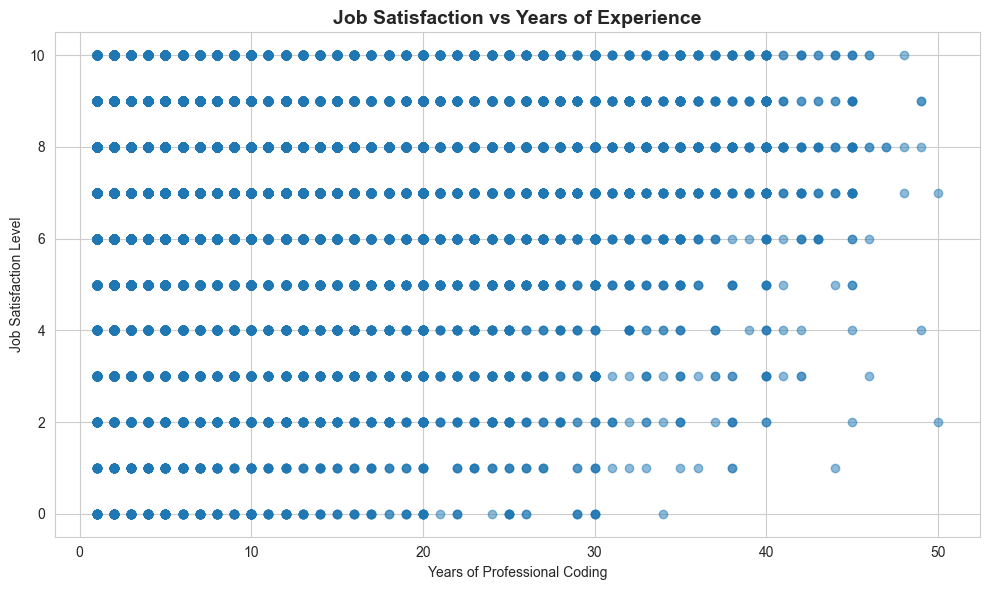

In [14]:
# Check if both columns exist
if 'YearsCodePro' in df_clean.columns and 'JobSat' in df_clean.columns:
    # Create a subset with both values present
    correlation_data = df_clean[['YearsCodePro', 'JobSat']].dropna()
    
    # Convert to numeric
    correlation_data['YearsCodePro'] = pd.to_numeric(correlation_data['YearsCodePro'], errors='coerce')
    
    # Map JobSat to numeric if it's categorical
    jobsat_mapping = {
        'Very dissatisfied': 1,
        'Slightly dissatisfied': 2,
        'Neither satisfied nor dissatisfied': 3,
        'Slightly satisfied': 4,
        'Very satisfied': 5
    }
    
    if correlation_data['JobSat'].dtype == 'object':
        correlation_data['JobSat_numeric'] = correlation_data['JobSat'].map(jobsat_mapping)
    else:
        correlation_data['JobSat_numeric'] = correlation_data['JobSat']
    
    # Remove any remaining NaN
    correlation_data = correlation_data.dropna(subset=['YearsCodePro', 'JobSat_numeric'])
    
    if len(correlation_data) > 0:
        # Calculate correlation
        correlation = correlation_data['YearsCodePro'].corr(correlation_data['JobSat_numeric'])
        print(f"Correlation between Experience and Job Satisfaction: {correlation:.3f}")
        
        # Create scatter plot
        plt.figure(figsize=(10, 6))
        plt.scatter(correlation_data['YearsCodePro'], correlation_data['JobSat_numeric'], alpha=0.5)
        plt.title('Job Satisfaction vs Years of Experience', fontsize=14, fontweight='bold')
        plt.xlabel('Years of Professional Coding')
        plt.ylabel('Job Satisfaction Level')
        plt.tight_layout()
        plt.show()
else:
    print("Required columns not found for correlation analysis")

## Employment vs Education Level

I'll analyze how employment status relates to education level.

Employment Status vs Education Level:
EdLevel                                             Associate degree (A.A., A.S., etc.)  \
Employment                                                                                
Employed, full-time                                                                1059   
Employed, full-time;Employed, part-time                                               9   
Employed, full-time;Independent contractor, fre...                                  104   
Employed, full-time;Independent contractor, fre...                                   11   
Employed, full-time;Independent contractor, fre...                                    0   
...                                                                                 ...   
Student, full-time;Student, part-time;Employed,...                                    0   
Student, full-time;Student, part-time;Retired                                         0   
Student, part-time                                  

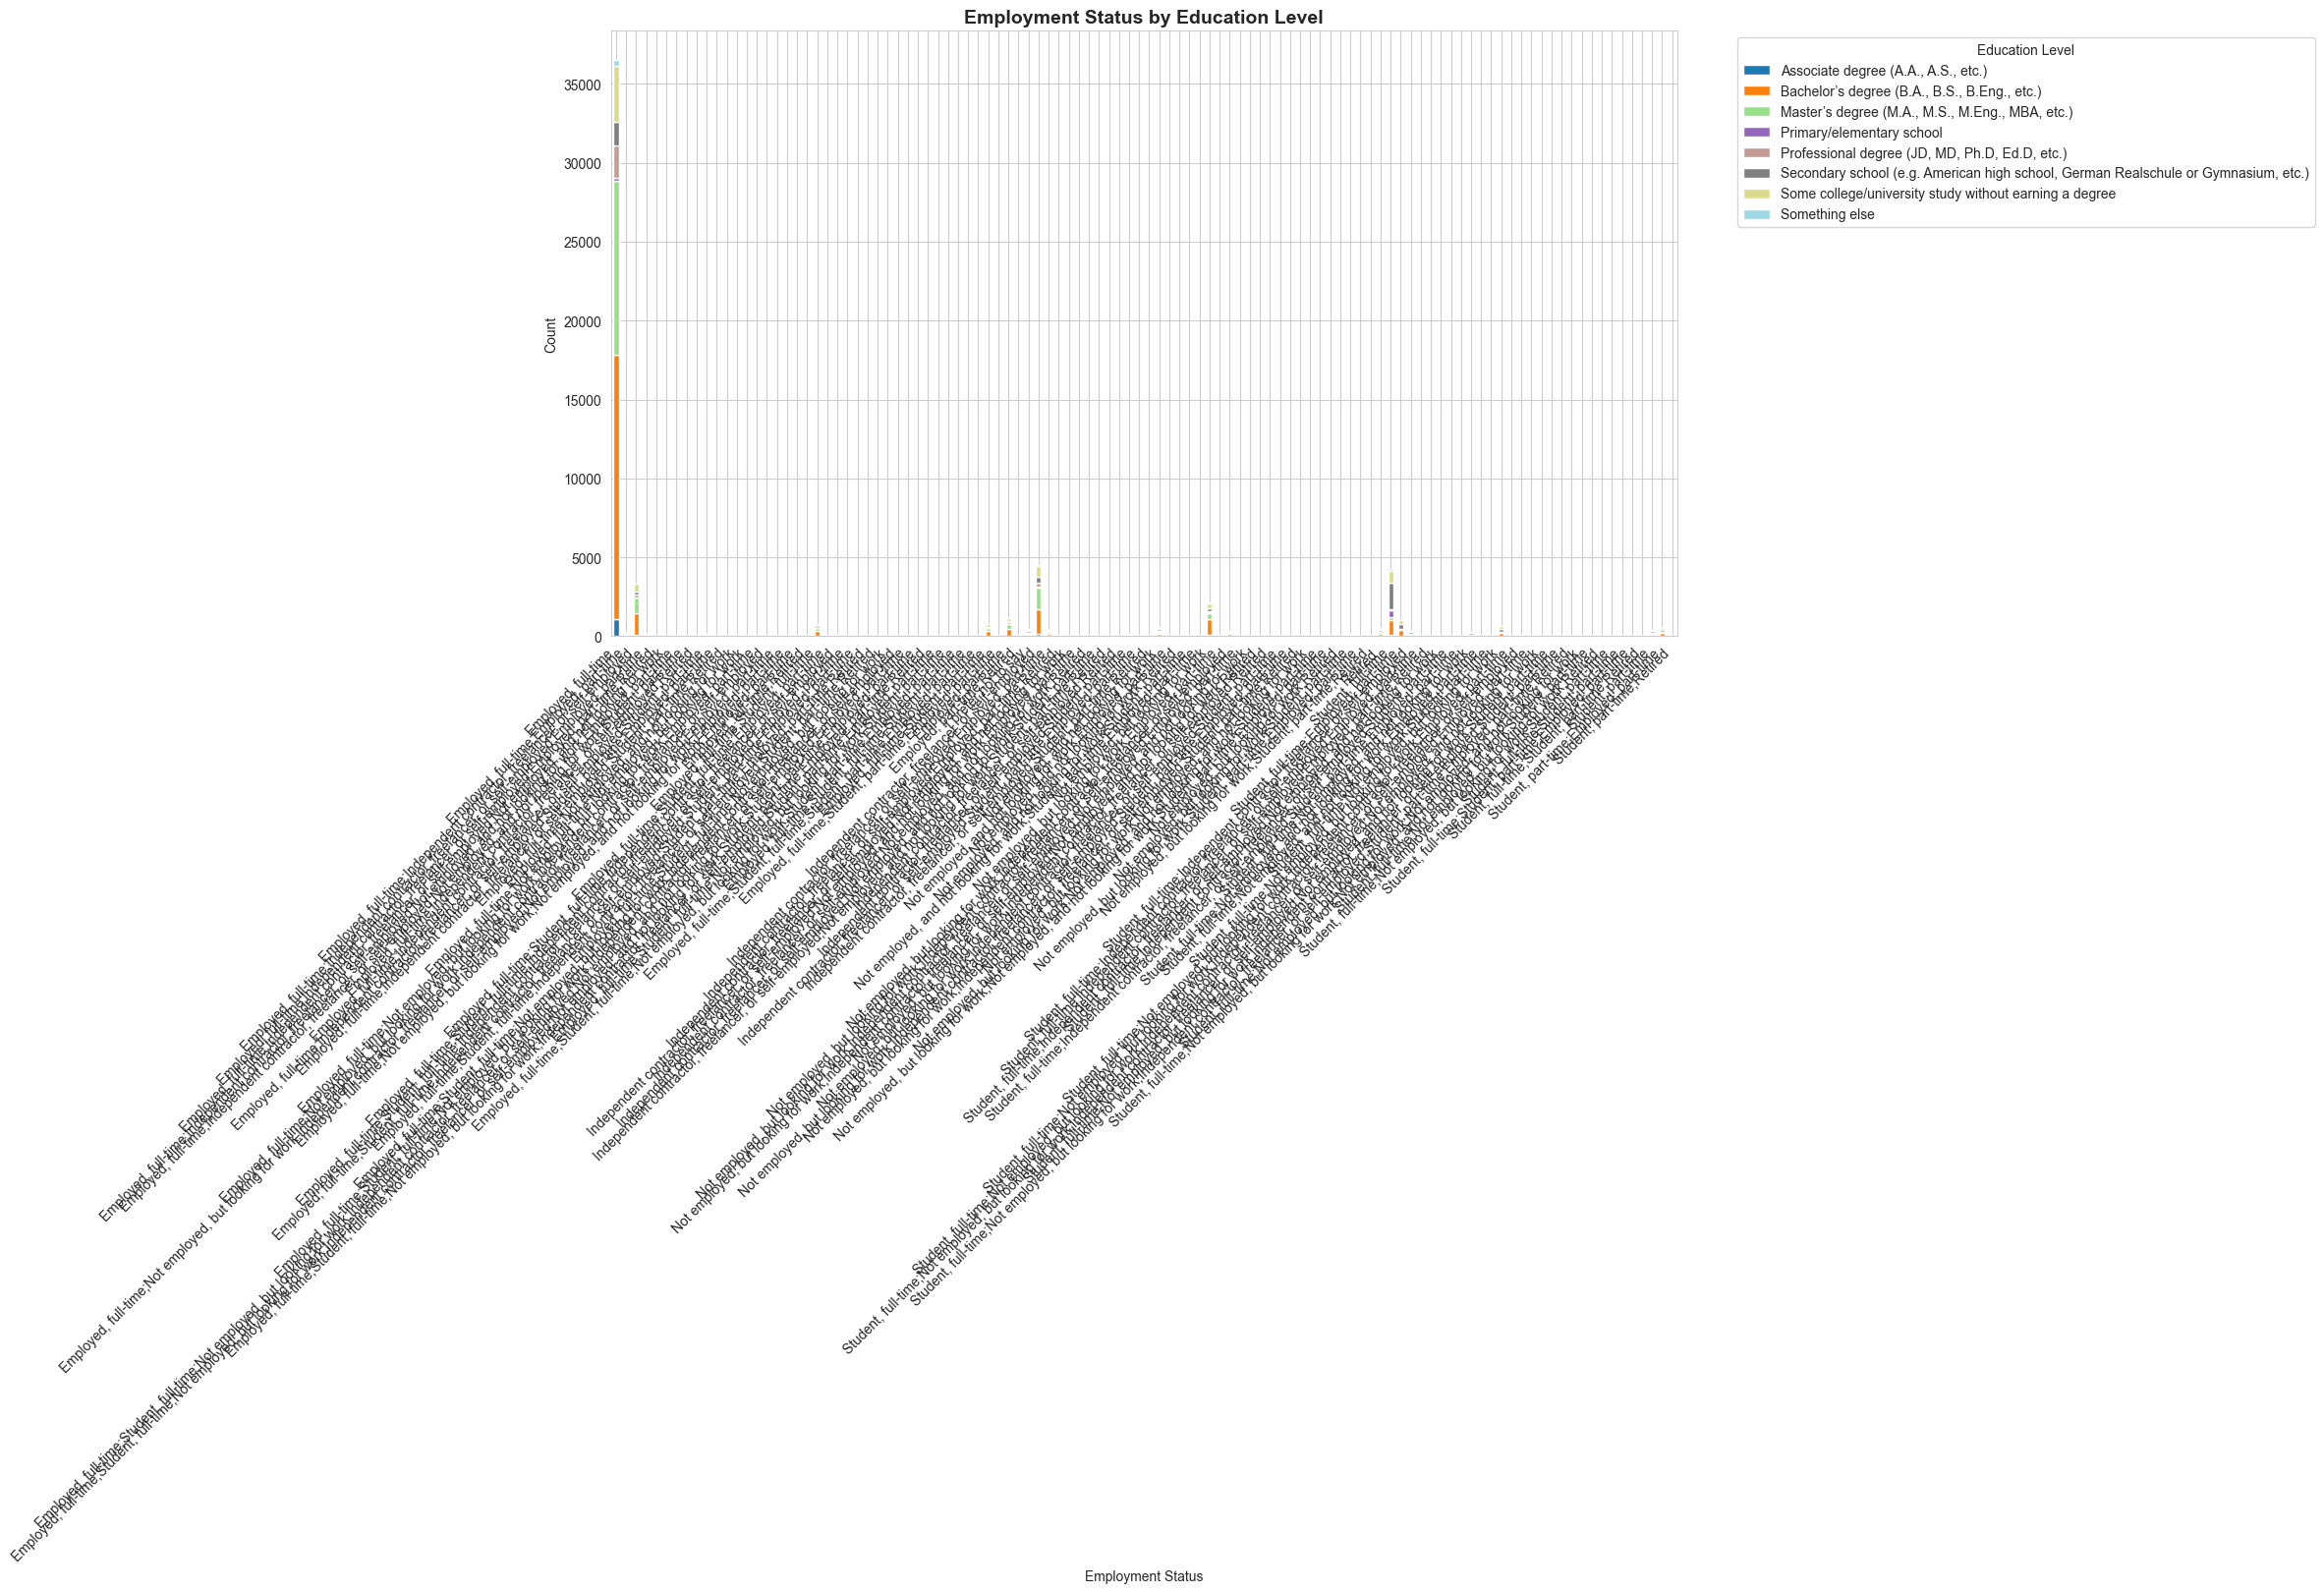

In [15]:
# Cross-tabulation of Employment and Education
if 'Employment' in df_clean.columns and 'EdLevel' in df_clean.columns:
    employment_ed = pd.crosstab(df_clean['Employment'], df_clean['EdLevel'])
    print("Employment Status vs Education Level:")
    print(employment_ed)
    
    # Visualize with stacked bar chart
    ax = employment_ed.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')
    ax.set_title('Employment Status by Education Level', fontsize=14, fontweight='bold')
    ax.set_xlabel('Employment Status')
    ax.set_ylabel('Count')
    ax.legend(title='Education Level', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Required columns not found for cross-tabulation")

## Saving the Cleaned Dataset

Finally, I'll save the cleaned and analyzed dataset.

In [16]:
# Save the cleaned dataset
df_clean.to_csv('survey_data_distribution_analysis.csv', index=False)
print("✅ Dataset saved as 'survey_data_distribution_analysis.csv'")
print(f"Final dataset shape: {df_clean.shape}")

✅ Dataset saved as 'survey_data_distribution_analysis.csv'
Final dataset shape: (65437, 114)


## Key Insights

Through this distribution analysis, I discovered:

- **Job Satisfaction Patterns**: The distribution shows how satisfied developers are in their roles
- **Programming Language Trends**: Identified the most commonly used and desired languages
- **Remote Work Preferences**: Regional variations in remote work adoption
- **Experience-Satisfaction Relationship**: How years of experience correlate with job satisfaction
- **Education-Employment Link**: The relationship between education level and employment status

These insights help paint a comprehensive picture of the developer landscape and can inform career decisions and industry trends.